# Supervised Learning
# NAMA : ANDI NURAINILAWATI
# NIM : 4222301083
# KLS : C PAGI

## Classification

### metode knn



In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('dataset_karyawan_missing.csv')
df.head()

,ID,Nama,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,1,Citra,NaN,5744870.0,53,9,Kontrak
1,2,Eka,HRD,5862014.0,39,9,Tetap
2,3,Citra,HRD,4894992.0,55,16,Tetap
3,4,Budi,QC,4606286.0,51,2,Kontrak
4,5,Dewi,HRD,4199766.0,44,7,Kontrak


### cek data

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               200 non-null    int64  
 1   Nama             200 non-null    object 
 2   Departemen       190 non-null    object 
 3   Gaji             190 non-null    float64
 4   Usia             200 non-null    int64  
 5   Lama_Kerja       200 non-null    int64  
 6   Status_Karyawan  200 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 11.1+ KB


ID                  0
Nama                0
Departemen         10
Gaji               10
Usia                0
Lama_Kerja          0
Status_Karyawan     0
dtype: int64

### data cleaning

INFO DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               200 non-null    int64  
 1   Nama             200 non-null    object 
 2   Departemen       190 non-null    object 
 3   Gaji             190 non-null    float64
 4   Usia             200 non-null    int64  
 5   Lama_Kerja       200 non-null    int64  
 6   Status_Karyawan  200 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 11.1+ KB

MISSING VALUE AWAL:
ID                  0
Nama                0
Departemen         10
Gaji               10
Usia                0
Lama_Kerja          0
Status_Karyawan     0
dtype: int64

MISSING VALUE SETELAH CLEANING:
Departemen         0
Gaji               0
Usia               0
Lama_Kerja         0
Status_Karyawan    0
dtype: int64

DATA SETELAH CLEANING:
  Departemen       Gaji  Usia  Lama_Kerja Sta

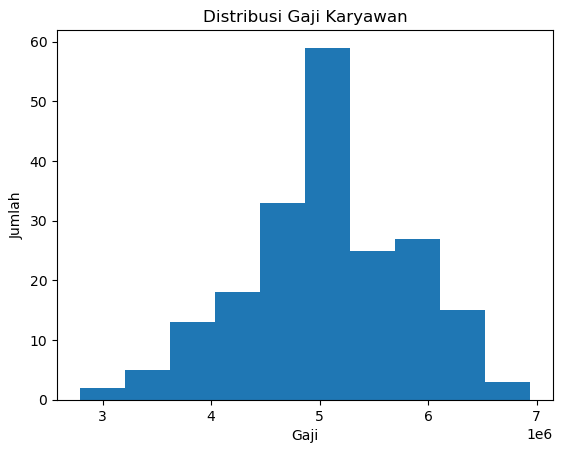

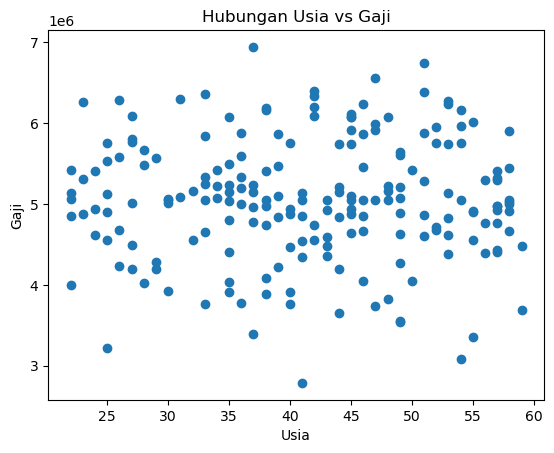

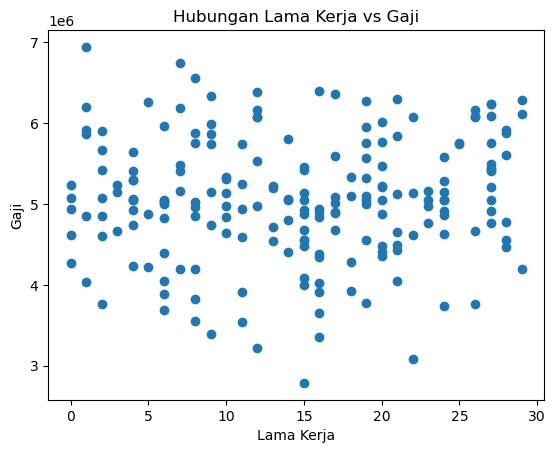

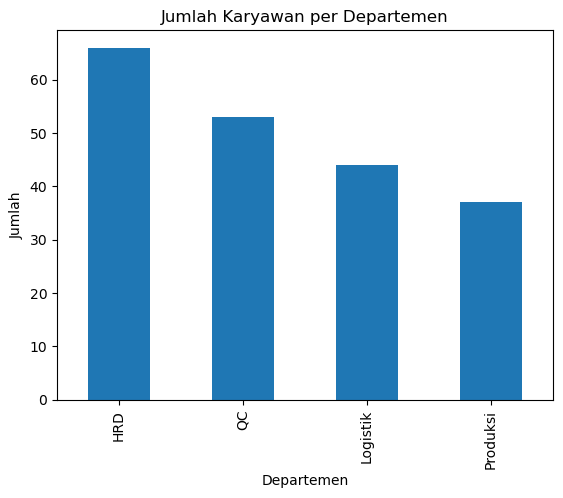

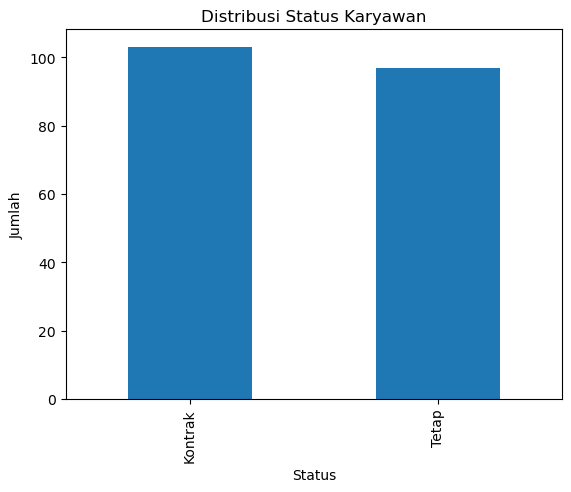

In [22]:
# ==============================
# STEP 1 — IMPORT LIBRARY
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer


# ==============================
# STEP 2 — LOAD DATA
# ==============================
df = pd.read_csv('dataset_karyawan_missing.csv')


# ==============================
# STEP 3 — CEK DATA AWAL
# ==============================
print("INFO DATA:")
df.info()

print("\nMISSING VALUE AWAL:")
print(df.isnull().sum())


# ==============================
# STEP 4 — BERSIHKAN NILAI KOSONG
# ==============================
df.replace("", np.nan, inplace=True)


# ==============================
# STEP 5 — PERBAIKI TIPE DATA
# ==============================
df['Gaji'] = pd.to_numeric(df['Gaji'], errors='coerce')
df['Usia'] = pd.to_numeric(df['Usia'], errors='coerce')
df['Lama_Kerja'] = pd.to_numeric(df['Lama_Kerja'], errors='coerce')


# ==============================
# STEP 6 — HANDLE MISSING VALUE
# ==============================
# Gaji → mean
imputer_gaji = SimpleImputer(strategy='mean')
df['Gaji'] = imputer_gaji.fit_transform(df[['Gaji']]).ravel()

# Departemen → modus
imputer_dept = SimpleImputer(strategy='most_frequent')
df['Departemen'] = imputer_dept.fit_transform(df[['Departemen']]).ravel()


# ==============================
# STEP 7 — DROP KOLOM TIDAK PERLU
# ==============================
df.drop(['ID', 'Nama'], axis=1, inplace=True)


# ==============================
# STEP 8 — CEK HASIL CLEANING
# ==============================
print("\nMISSING VALUE SETELAH CLEANING:")
print(df.isnull().sum())

print("\nDATA SETELAH CLEANING:")
print(df.head())


# ======================================
# STEP 9 — VISUALISASI DATA
# ======================================

# 1. Distribusi Gaji
plt.figure()
plt.hist(df['Gaji'])
plt.title("Distribusi Gaji Karyawan")
plt.xlabel("Gaji")
plt.ylabel("Jumlah")
plt.show()


# 2. Hubungan Usia vs Gaji
plt.figure()
plt.scatter(df['Usia'], df['Gaji'])
plt.title("Hubungan Usia vs Gaji")
plt.xlabel("Usia")
plt.ylabel("Gaji")
plt.show()


# 3. Hubungan Lama Kerja vs Gaji
plt.figure()
plt.scatter(df['Lama_Kerja'], df['Gaji'])
plt.title("Hubungan Lama Kerja vs Gaji")
plt.xlabel("Lama Kerja")
plt.ylabel("Gaji")
plt.show()


# 4. Jumlah Karyawan per Departemen
plt.figure()
df['Departemen'].value_counts().plot(kind='bar')
plt.title("Jumlah Karyawan per Departemen")
plt.xlabel("Departemen")
plt.ylabel("Jumlah")
plt.show()


# 5. Status Karyawan
plt.figure()
df['Status_Karyawan'].value_counts().plot(kind='bar')
plt.title("Distribusi Status Karyawan")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Sex'] = le.fit_transform(train['Sex'])
train['Embarked'] = le.fit_transform(train['Embarked'])
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


Encoding Data Kategorikal

In [6]:
le_dept = LabelEncoder()
le_status = LabelEncoder()

df['Departemen'] = le_dept.fit_transform(df['Departemen'])
df['Status_Karyawan'] = le_status.fit_transform(df['Status_Karyawan'])

# Feature Selection

In [7]:
X = df[['Usia', 'Lama_Kerja', 'Departemen', 'Status_Karyawan']]
y = df['Gaji']

### Split Data

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [ ]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

### Model KNN

In [14]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [15]:
y_pred = knn.predict(X_test)


In [ ]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


Evaluasi Model

In [16]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 778621.9107802332
R2 Score: -0.2422861592168446


Prediksi Data Baru

In [20]:
data_input = pd.DataFrame({
    'Usia': [25, 40, 35],
    'Lama_Kerja': [2, 15, 10],
    'Departemen': ['HRD', 'Produksi', 'QC'],
    'Status_Karyawan': ['Kontrak', 'Tetap', 'Tetap']
})

# Encoding
data_input['Departemen'] = le_dept.transform(data_input['Departemen'])
data_input['Status_Karyawan'] = le_status.transform(data_input['Status_Karyawan'])

# Scaling
data_scaled = scaler.transform(data_input)

# Prediksi
prediksi = knn.predict(data_scaled)

# Gabung hasil
data_input['Prediksi_Gaji'] = prediksi

print(data_input)

   Usia  Lama_Kerja  Departemen  Status_Karyawan  Prediksi_Gaji
0    25           2           0                0      5588599.8
1    40          15           2                1      4451608.8
2    35          10           3                1      4991024.8


2. Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari 
studi kasus masing-masing. (20 Point, CLOP-4) 

Feature engineering adalah proses mengolah, memilih, dan membentuk variabel (fitur) dari data mentah agar lebih relevan dan informatif bagi model machine learning. Tujuannya bukan sekadar “membersihkan data”, tetapi meningkatkan kemampuan model dalam menangkap pola sehingga prediksi jadi lebih akurat dan stabil.

 Peran Feature Engineering dalam Machine Learning
Meningkatkan akurasi model
Fitur yang tepat membuat model lebih mudah memahami hubungan antar variabel.
Mengurangi noise (data tidak relevan)
Fitur yang tidak penting bisa dihapus agar model tidak “bingung”.
Menyesuaikan data dengan algoritma
Misalnya KNN butuh data numerik dan berskala → perlu encoding & scaling.
Menyederhanakan kompleksitas data
Menggabungkan atau membuat fitur baru bisa membuat pola lebih jelas.
Mengatasi keterbatasan data mentah
Data awal sering belum siap pakai → perlu diolah dulu.
 Contoh dari Studi Kasus (Prediksi Gaji Karyawan)

Pada kasus kamu:
Prediksi gaji berdasarkan Usia, Lama Kerja, Departemen, Status Karyawan

 1. Handling Missing Value
Masalah: Ada data kosong di kolom Gaji dan Departemen
Solusi:
Gaji → isi dengan mean
Departemen → isi dengan modus

Ini penting agar model tetap bisa dilatih tanpa error

2. Encoding Data Kategorikal
Masalah:
Kolom Departemen dan Status_Karyawan berupa teks
Solusi:
Ubah jadi angka dengan Label Encoding

Contoh:

HRD → 0
Produksi → 1
QC → 2
Logistik → 3

KNN hanya bisa menghitung jarak jika datanya numerik

3. Feature Selection
Menghapus kolom yang tidak berpengaruh:
ID
Nama

Karena tidak relevan terhadap gaji

4. Feature Scaling (Sangat Penting di KNN)
Masalah:
Skala berbeda:
Usia (20–60)
Lama kerja (0–30)
Gaji (jutaan)
Solusi:
Gunakan StandardScaler

 Tanpa scaling → KNN jadi bias (fitur besar mendominasi)

 5. (Opsional) Feature Creation

Contoh pengembangan:

Membuat fitur baru:
Rasio Pengalaman = Lama_Kerja / Usia

 Bisa bantu model menangkap pola lebih kompleks
 
 Kesimpulan

Feature engineering adalah tahap penting yang menentukan kualitas model.
Dalam studi kasus ini, langkah seperti cleaning, encoding, dan scaling sangat berpengaruh terhadap keberhasilan model KNN dalam memprediksi gaji secara objektif dan akurat.

3. Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing, 
Jelaskan? 
(20 Point, CLO-4)

Confusion Matrix dan Metrik Evaluasi dalam Machine Learning
🔹 A. Pengertian Confusion Matrix

Confusion matrix adalah alat evaluasi yang digunakan untuk mengukur kinerja model klasifikasi dengan membandingkan antara hasil prediksi dan nilai aktual. Confusion matrix berbentuk tabel yang menunjukkan jumlah prediksi benar dan salah dalam beberapa kategori.

Komponen utama confusion matrix:

True Positive (TP) → prediksi positif dan benar
True Negative (TN) → prediksi negatif dan benar
False Positive (FP) → prediksi positif tetapi sebenarnya negatif
False Negative (FN) → prediksi negatif tetapi sebenarnya positif

Dari confusion matrix, dapat diturunkan beberapa metrik:

Accuracy → tingkat ketepatan keseluruhan
Precision → ketepatan prediksi positif
Recall → kemampuan menemukan semua data positif
F1-Score → keseimbangan antara precision dan recall
🔹 B. Keterkaitan dengan Studi Kasus

Pada studi kasus yang dikerjakan, yaitu prediksi gaji karyawan menggunakan algoritma KNN, tipe permasalahan yang dihadapi adalah:

Regresi (nilai kontinu berupa angka gaji)

Sehingga:

❌ Confusion matrix tidak digunakan secara langsung
✔ Digunakan metrik evaluasi regresi

Namun, secara konsep:
 Jika gaji dikategorikan (misalnya: rendah, sedang, tinggi), maka confusion matrix bisa digunakan

🔹 C. Metrik Evaluasi yang Digunakan (Regresi)
1. Mean Squared Error (MSE)

Mengukur rata-rata kuadrat selisih antara nilai aktual dan prediksi.

MSE=
n
1
	​

∑(y
asli
	​

−y
prediksi
	​

)
2

Karakteristik:

Sensitif terhadap error besar
Digunakan sebagai dasar RMSE
2. Root Mean Squared Error (RMSE)

Akar dari MSE, sehingga satuannya sama dengan data asli (gaji).

RMSE=
MSE
	​


 Interpretasi:

Nilai kecil → model akurat
Nilai besar → prediksi kurang baik

Ini metrik paling mudah dipahami dalam konteks bisnis

 3. R² Score (Koefisien Determinasi)

Mengukur seberapa besar variasi data dapat dijelaskan oleh model.

R
2
=1−
SS
tot
	​

SS
res
	​

	​


Interpretasi:

1 → model sangat baik
0 → model tidak menjelaskan data
< 0 → model sangat buruk
🔹 D. Contoh dari Studi Kasus

Misalnya:

Gaji aktual: Rp5.000.000
Prediksi model: Rp5.200.000

Error = Rp200.000

Jika banyak data memiliki error kecil, maka:

RMSE kecil
R² mendekati 1
 Model dianggap baik

Kesimpulan
Confusion matrix adalah alat evaluasi untuk klasifikasi, bukan regresi
Studi kasus prediksi gaji menggunakan pendekatan regresi
Oleh karena itu, metrik yang digunakan adalah:
MSE
RMSE
R² Score
Evaluasi ini penting untuk memastikan model dapat memberikan prediksi yang akurat dan dapat dipercaya dalam pengambilan keputusan HR